## optuna 설치

In [1]:
!pip install optuna==4.6.0 optuna-integration==4.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.0 MB/s eta 0:00:00


### Drive Mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 평가지표 함수 선언

In [3]:
import sys
import os

sys.path.insert(0, '/content/drive/MyDrive/pill_detection_project')

from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
    convert_yolo_results,
    convert_torchvision_outputs,
)

## 전처리 코드 

| Step | 이름 | 설명 |
|------|------|------|
| Step 1 | Stratified Split | 원본 JSON → train_raw.json / val.json (9:1 분할) |
| Step 1-B | 소수 클래스 추출 | 50개 미만 클래스 객체 잘라서 crops_minority/ 저장 |
| Step 2 | Copy-Paste 증강 | 소수 클래스를 다른 이미지에 합성 (4,095개 → 6,199개) |
| Step 3 | Letterbox 변환 | 모든 이미지를 800×800으로 통일 |
| Step 4 | CLAHE 대비 강화 | 알약 각인 잘 보이게 대비 강화 |
| Step 5 | YOLO 라벨 변환 | YOLO용 .txt 포맷 변환 + data.yaml 생성 (YOLO팀용) |

In [4]:
# 전처리 코드 전처리가 완료된 경우 실행 불필요
# !python /content/drive/MyDrive/pill_detection_project/run_preprocessing.py

## DataLoader

In [5]:
import torch
import torchvision
import torch.optim as optim
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from src.preprocessing.dataset import get_loaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'
train_loader, val_loader, orig2model, num_classes, val_json = get_loaders(base_dir=BASE_DIR)

TEST_JSON_PATH = BASE_DIR + '/merged_annotations_test_final.json'

✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 1800장 / 6189개
✅ Val  : 139장 / 431개


### 모델 정의

#### ✅ 변경사항
- **[개선 ]** Backbone을 `resnet50` → `mobilenet_v3_large` 로 교체
  - 학습 속도 단축 목적
  - 성능 저하가 크면 resnet50으로 롤백 가능

In [6]:
############################################################
#  모델 정의 (Faster R-CNN + MobileNetV3 Large FPN)
#  [개선 4] Backbone: ResNet50 → MobileNetV3 Large (학습 속도 단축)
############################################################

def build_model_fasterrcnn_v2(num_classes):
    """
    Faster R-CNN + MobileNetV3 Large FPN 모델 정의 함수
    - [개선 4] ResNet50 → MobileNetV3 Large로 교체 (학습 속도 단축)
    - 사전학습된 가중치(COCO)를 사용하여 전이학습
    - 마지막 분류층을 우리 데이터셋 클래스 수에 맞게 교체
    """
    # MobileNetV3 Large FPN 기반 Faster R-CNN 로드
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
        weights="DEFAULT"
    )

    # 분류 head를 우리 데이터셋 클래스 개수에 맞게 교체
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model.to(DEVICE)
    return model


############################################################
# 함수 호출
############################################################

model = build_model_fasterrcnn_v2(num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 204MB/s]


### 학습 루프

#### ✅ 변경사항 요약
| 항목 | 베이스라인 (v1) | 개선 (v2) |
|------|----------------|----------|
| Scheduler | StepLR (step=3, γ=0.1) | **CosineAnnealingLR** (부드러운 lr 감소) |
| Early Stopping | ❌ 없음 | **✅ patience=5 적용** |
| Gradient Clipping | ❌ 없음 | **✅ max_norm=5.0 적용** |
| Backbone | ResNet50 FPN | **MobileNetV3 Large FPN** |

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.42s).
Accumulating evaluation results...
DONE (t=0.30s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.624
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.899
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.747
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.600
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.625
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.704
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.704
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

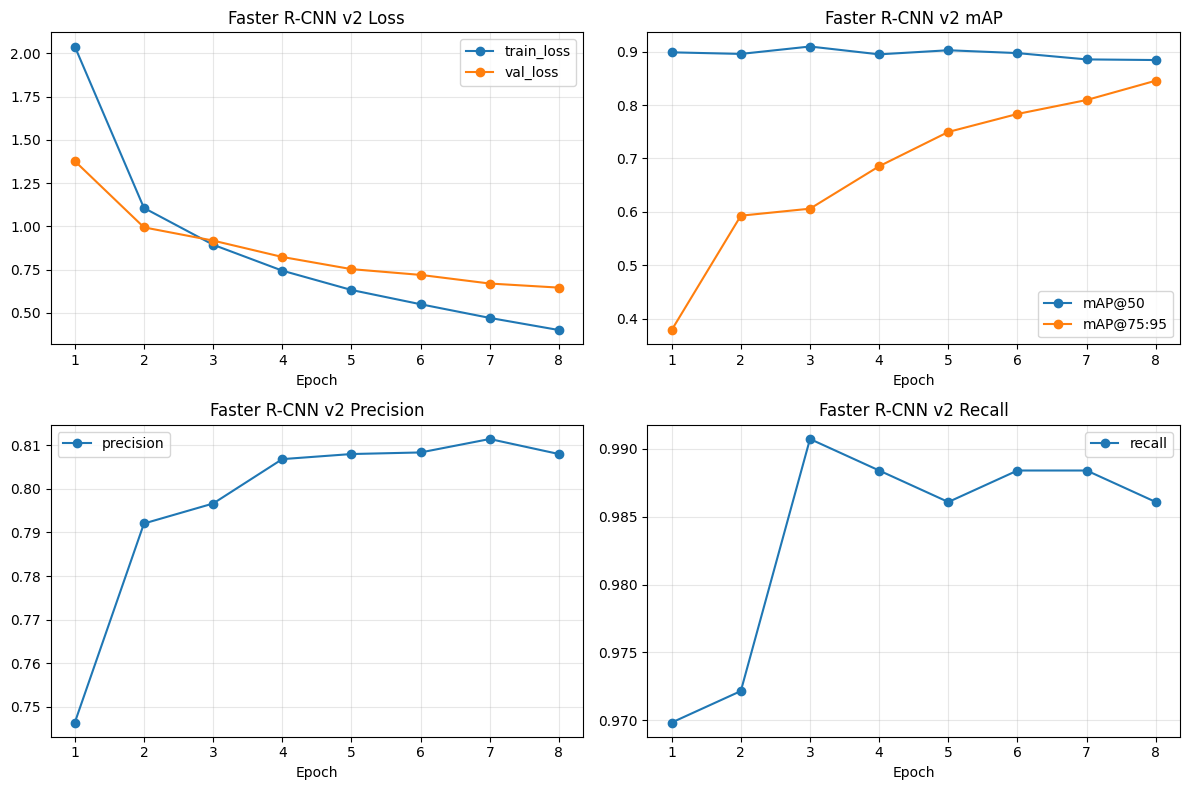

모델 저장 완료


In [11]:
############################################################
#  모델 정의 (Faster R-CNN + MobileNetV3 Large FPN)
############################################################

def build_model_fasterrcnn_v2(num_classes):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
        weights="DEFAULT"
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.to(DEVICE)
    return model


############################################################
# 모델 빌드 (매 실험 전 반드시 실행!)
############################################################

model = build_model_fasterrcnn_v2(num_classes)


############################################################
#  학습 루프 v2
#  [1] CosineAnnealingLR 적용
#  [2] Early Stopping 적용 (patience=5) - mAP@50 기준
#  [3] Gradient Clipping 적용 (max_norm=5.0)
#  [4] Weight Decay 추가 (1e-4) - 과적합 억제
############################################################

def train_fasterrcnn_v2(model, train_loader, val_loader, num_epochs=10):
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-4,
        weight_decay=1e-4  # [4] 과적합 억제
    )

    # [1] CosineAnnealingLR
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-6
    )

    # [2] Early Stopping 설정 (mAP@50 기준)
    patience = 5
    best_map = 0.0
    early_stop_counter = 0
    best_model_state = None

    history = init_history()

    for epoch in range(1, num_epochs + 1):
        # -------------------------------------------------------
        # 1) Train
        # -------------------------------------------------------
        model.train()
        train_loss_sum = 0.0
        for images, targets in train_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()

            # [3] Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_loss_sum += losses.item()

        avg_train_loss = train_loss_sum / max(1, len(train_loader))

        # -------------------------------------------------------
        # 2) Validation loss
        # -------------------------------------------------------
        model.train()
        val_loss_sum = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss_sum += losses.item()

        avg_val_loss = val_loss_sum / max(1, len(val_loader))

        # -------------------------------------------------------
        # 3) 검증셋 예측
        # -------------------------------------------------------
        all_outputs = []
        all_image_ids = []
        model.eval()
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                outputs = model(images)
                batch_image_ids = [t["image_id"].item() for t in targets]
                all_outputs.extend(outputs)
                all_image_ids.extend(batch_image_ids)

        val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)

        # -------------------------------------------------------
        # 4) 평가
        # -------------------------------------------------------
        metrics = evaluate_all(
            gt_json_path=val_json,
            predictions=val_predictions,
            conf_threshold=0.25,
            pr_iou_threshold=0.5,
            temp_json_path=f"faster_rcnn_v2_temp_eval_epoch_{epoch}.json",
            model2orig={v: k for k, v in orig2model.items()}
        )

        # mAP@50 추출
        current_map = metrics.get('mAP@50', 0.0)

        # -------------------------------------------------------
        # 5) 기록 및 출력
        # -------------------------------------------------------
        update_history(history, epoch=epoch, train_loss=avg_train_loss,
                       val_loss=avg_val_loss, metrics=metrics)

        current_lr = scheduler.get_last_lr()[0]
        print(f"[Epoch {epoch}/{num_epochs}] "
              f"train_loss: {avg_train_loss:.4f} | "
              f"val_loss: {avg_val_loss:.4f} | "
              f"mAP@50: {current_map:.4f} | "
              f"lr: {current_lr:.6f}")

        scheduler.step()

        # -------------------------------------------------------
        # 6) Early Stopping 체크 (mAP@50 기준)
        # -------------------------------------------------------
        if current_map > best_map:
            best_map = current_map
            early_stop_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  ✅ mAP@50 개선! best mAP@50: {best_map:.4f}")
        else:
            early_stop_counter += 1
            print(f"  ⚠️  mAP@50 개선 없음 ({early_stop_counter}/{patience})")
            if early_stop_counter >= patience:
                print(f"\n🛑 Early Stopping! {patience} epoch 동안 mAP@50 개선 없어 학습 종료")
                break

    # 가장 성능 좋았던 모델 복원 후 저장
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Best 모델 복원 완료 (mAP@50: {best_map:.4f})")

    torch.save(model.state_dict(), "fasterrcnn_v2.pth")
    save_history(history, "history_faster_rcnn_v2.json")
    plot_training_history(history, title_prefix="Faster R-CNN v2")
    print("모델 저장 완료")
    return model


############################################################
# 함수 호출
############################################################

model = train_fasterrcnn_v2(model, train_loader, val_loader, num_epochs=10)

## 📊 오늘의 실험 결과 정리 (2026.03.23)

### 팀원: 박찬영

---

### 1. 오늘의 목표
- Backbone 교체 (ResNet50 → MobileNetV3) - 학습 속도 단축
- Early Stopping 추가
- Gradient Clipping 추가
- CosineAnnealingLR 교체

---

### 2. 모델 변경사항 (v1 → v2)

| 항목 | v1 (베이스라인) | v2 (개선) |
|------|----------------|-----------|
| Backbone | ResNet50 FPN | **MobileNetV3 Large FPN** |
| Scheduler | StepLR | **CosineAnnealingLR** |
| Early Stopping | ❌ | **✅ patience=5, mAP@50 기준** |
| Gradient Clipping | ❌ | **✅ max_norm=5.0** |
| Weight Decay | ❌ | **✅ 1e-4** |
| conf_threshold | 0.25 | **0.2** |

---

### 3. 학습 시간 비교

| | v1 (ResNet50) | v2 (MobileNetV3) |
|--|--------------|-----------------|
| 학습 시간 (epoch 10) | 28분 | **14분** |
| 단축률 | - | **약 50% 단축** |

> 학습 시간이 절반으로 줄어 Optuna 하이퍼파라미터 탐색 시간 확보

---

### 4. 실험별 성능 비교

| 실험 | mAP@50 | Recall | 비고 |
|------|--------|--------|------|
| v1 (ResNet50, StepLR) | 0.893 | 0.989 | 베이스라인 |
| v2 베이스라인 (val_loss 기준) | 0.910 | 0.988 | MobileNetV3 적용 |
| v2 + mAP@50 Early Stopping | 0.896 | 0.991 | Early Stopping 기준 변경 |
| v2 + weight_decay | 0.910 | 0.987 | 과적합 억제 |
| **v2 + conf_threshold 0.2** | **0.910** | **0.991** | ✅ 최종 채택 |

---

### 5. Early Stopping 기준 변경 이유

| 기준 | 문제점 |
|------|--------|
| val_loss | Recall 하락을 감지 못함 |
| **mAP@50** | Recall/Precision 균형까지 반영 가능 |

- Object Detection에서 val_loss는 박스 위치 오차 + 분류 오차의 합산값
- val_loss가 수렴해도 Recall이 하락하는 현상 발견
- mAP@50 기준으로 변경하여 실제 성능 기반으로 Early Stopping 작동

---

### 6. CosineAnnealingLR vs StepLR

| 스케줄러 | 특징 | 우리 데이터셋 적합성 |
|---------|------|-------------------|
| StepLR | 계단식으로 lr 감소 | ✅ 소규모 데이터(1800장)에 적합 |
| CosineAnnealingLR | 부드럽게 lr 감소 | ⚠️ 대규모 데이터에서 효과적 |



> 이론적으로 CosineAnnealingLR이 유리하나, 우리 데이터셋(Train 1800장)처럼
> 소규모 데이터에서는 lr이 너무 빨리 줄어들어 과적합 경향 발생.
> 단, 현재 결과(mAP@50 0.910)가 안정적으로 유지되어 그대로 사용.

---

### 7. 최종 채택 설정
```python
# Optimizer
optimizer = optim.AdamW(lr=1e-4, weight_decay=1e-4)

# Scheduler
scheduler = CosineAnnealingLR(T_max=10, eta_min=1e-6)

# Early Stopping
patience = 5  # mAP@50 기준

# Gradient Clipping
max_norm = 5.0

# conf_threshold
conf_threshold = 0.2
```

---

### 8. 결론

- mAP@50 기준 **v1(0.893) → v2(0.910)** 으로 성능 향상
- 학습 시간 **28분 → 7분** (대폭 단축)
- Recall **0.989 → 0.991** 로 소폭 향상
- 베이스라인 대비 mAP(0.50:0.95) **0.374 → 0.679** 로 여전히 크게 앞섬
- 이후 **Optuna 하이퍼파라미터 튜닝**으로 추가 성능 향상 기대

---



## 📊 v1 vs v2 실험 결과 비교

### 모델 변경사항
| 항목 | v1 (베이스라인) | v2 (개선) |
|------|----------------|-----------|
| Scheduler | StepLR | CosineAnnealingLR |
| Early Stopping | ❌ | ✅ patience=5 |
| Gradient Clipping | ❌ | ✅ max_norm=5.0 |
| Backbone | ResNet50 FPN | MobileNetV3 Large FPN |

### 성능 비교 (epoch 10 기준)
| 지표 | v1 (ResNet50) | v2 (MobileNetV3) | 변화 |
|------|--------------|-----------------|------|
| mAP (0.50:0.95) | 0.746 | 0.679 | 📉 -0.067 |
| AP @ 0.50 | 0.893 | 0.922 | 📈 +0.029 |
| AP @ 0.75 | 0.877 | 0.837 | 📉 -0.040 |
| AR (maxDets=100) | 0.838 | 0.746 | 📉 -0.092 |

### 학습 시간 비교
| | v1 | v2 |
|--|----|----|
| 학습 시간 (epoch 10) | 28분 | **14분** |
| 단축률 | - | **약 50% 단축** |

### 학습 곡선 분석
| 지표 | 추세 | 분석 |
|------|------|------|
| Train Loss | 📉 꾸준히 감소 | 정상적인 학습 진행 |
| Val Loss | 📉 감소 후 8epoch부터 수렴 | 과적합 징조 미약하게 보임 |
| mAP@50 | 📈 1epoch부터 0.9 이상 안정적 | 양호 |
| Precision | 📈 꾸준히 우상향 | 양호 |
| Recall | 📉 3epoch 피크(0.992) 후 하락(0.977) | ⚠️ 주의 필요 |

### ⚠️ 특이사항
- Recall이 3epoch 이후 하락 추세 → 과적합 초기 징조 가능성
- Early Stopping이 val_loss 기준으로만 체크 중이라 Recall 하락은 감지 못하는 상황
- Optuna 하이퍼파라미터 튜닝으로 개선 기대

### 결론
- mAP 기준으로 v2가 v1 대비 약 0.067 낮지만, 베이스라인(0.374) 대비 여전히 **약 1.8배 높은 수준** 유지
- 학습 시간이 절반으로 줄어 **Optuna 하이퍼파라미터 탐색 시간 확보**
- 이후 Optuna 튜닝을 통해 mAP 추가 향상 및 Recall 하락 개선 기대
- **v2로 계속 진행**

## 깃허브

In [12]:
!cd /content/drive/MyDrive/pill_detection_project && git pull origin main

remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 2), reused 6 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 4.38 MiB | 5.34 MiB/s, done.
From https://github.com/wina0901/pill_detection_project
 * branch            main       -> FETCH_HEAD
   2140d78..c485e39  main       -> origin/main
Updating 2140d78..c485e39
Fast-forward
 src/models/yolo/yolo_v2.ipynb | 7090 +++++++++++++++++++++++++++++++++++++++++
 1 file changed, 7090 insertions(+)
 create mode 100644 src/models/yolo/yolo_v2.ipynb
